<a href="https://colab.research.google.com/github/JFavela1/IPYNB/blob/main/CS561_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Note:
For right now, I did not create any API keys, so you would have to manually upload the 2 datasets and LM dictionary csv to the folder on the left tab to use them

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

## Import 2 Dataset and check its properties

In [ ]:
df = pd.read_csv("./sp500_headlines_2008_2024.csv")

df.columns = ["headline", "date", "close"]
df["date"] = pd.to_datetime(df["date"])
df = df.dropna()
df = df.sort_values("date").reset_index(drop=True)

In [ ]:
daily_close = df.drop_duplicates("date")[["date", "close"]].copy()
daily_close = daily_close.sort_values("date")

daily_close["next_close"] = daily_close["close"].shift(-1)
daily_close["return"] = (daily_close["next_close"] - daily_close["close"]) / daily_close["close"]
daily_close["label"] = (daily_close["return"] > 0).astype(int)

daily_close = daily_close.dropna()


In [ ]:
daily_close.head()

,date,close,next_close,return,label
0,2008-01-02,1447.16,1447.16,0.000000,0
3,2008-01-03,1447.16,1416.18,-0.021407,0
4,2008-01-07,1416.18,1409.13,-0.004978,0
5,2008-01-09,1409.13,1420.33,0.007948,1
7,2008-01-10,1420.33,1310.50,-0.077327,0


## Build Preprocess functions for each model.
FinBERT requires light preprocessing because the model is trained to read real headlines and aspects, such as capitalization matters. Dictionary model requires heavy preprocessing as it does not care about context nor word order

According to Kaggle for the Sentiment Analysis Dataset:
Here are the data operations made on the texts:

Nulls removal

Duplicates removal

Balancing (so there are as many texts of each sentiment)

Stripping (remove any leading and trailing white spaces and new lines)

URL removal

Contractions Expansion (e.g. converting "it's" to "it is")

Shuffling

In [ ]:
def preprocess_finbert(text):
  text = str(text)
  text = re.sub(r'<[^<>]*>', ' ', text)
  text = re.sub(r'\s+', ' ', text)
  text = text.strip()

  return text

'''
The LM Dictionary preprocess function will lowercase the text, remove html tags
(only because Sentiment Analysis Dataset Kaggle said to add), remove characters other than a space and alphabets,
remove extra spaces and tokenize the text.
'''
def preprocess_dictionary(text):
  text = str(text).lower() # str in case if text was not a string like NaN. The str could be removed if no none string will be passed
  text = re.sub(r'<[^<>]*>', ' ', text) # Remove html tags since Kaggle said necessary
  text = re.sub(r'[^a-z\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text) # Remove extra spaces
  text = text.split() # Tokenization (and removes leading/trailing spaces)

  return text

## Load LM Dictionary and create a list of positive and negative words

In [ ]:
lm_dict = pd.read_csv("Loughran-McDonald_MasterDictionary_1993-2025.csv")

lm_dict.head()

,Word,Seq_num,Word Count,Word Proportion,Average Proportion,Std Dev,Doc Count,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Complexity,Syllables,Source
0,AARDVARK,1,814,3.085383e-08,2.022181e-08,4.059339e-06,158,0,0,0,0,0,0,0,0,2,12of12inf
1,AARDVARKS,2,3,1.137119e-10,7.898767e-12,8.829342e-09,1,0,0,0,0,0,0,0,0,2,12of12inf
2,ABACI,3,9,3.411357e-10,1.067549e-10,5.054031e-08,7,0,0,0,0,0,0,0,0,3,12of12inf
3,ABACK,4,29,1.099215e-09,6.073925e-10,1.523804e-07,28,0,0,0,0,0,0,0,0,2,12of12inf
4,ABACUS,5,9921,3.760453e-07,3.836730e-07,3.392121e-05,1355,0,0,0,0,0,0,0,0,3,12of12inf


In [ ]:
# Create a list by keep words of Positive/Negative that is not 0, keep the Word column, and lowercase the word
pos_words = list(set(lm_dict[lm_dict["Positive"] != 0]["Word"].str.lower()))
neg_words = list(set(lm_dict[lm_dict["Negative"] != 0]["Word"].str.lower()))

print(pos_words[:10])
print(neg_words[:10])

['friendly', 'delighted', 'beneficially', 'accomplish', 'solving', 'excitement', 'attainments', 'valuable', 'collaborating', 'confident']
['deviation', 'unavoidable', 'cut', 'untimely', 'objection', 'undelivered', 'disallows', 'disassociates', 'illicit', 'malice']


In [ ]:
def lm_sentiment(tokens):
  # Collect total positive and negative words in the tokens/sentence
  pos_count = sum(1 for w in tokens if w in pos_words)
  neg_count = sum(1 for w in tokens if w in neg_words)
  total_count = pos_count + neg_count

  # Calculate the sentiment score (if-statement in case total_words is 0 and is divisionByZero error)
  score = (pos_count - neg_count) / total_count if total_count > 0 else 0
  return score

## Load FinBERT and Sentiment Score Calculation Function

In [ ]:
# Load Pipeline method and Manual method (I don't know which one you guys want)
#finbert = pipeline("text-classification", model="ProsusAI/finbert", return_all_scores=True) # return_all_score should give all sentiment score results

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
model.eval()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 42838.17it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def finbert_batch(texts, batch_size=32):
    all_scores = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=-1)

        probs = probs.cpu()

        id2label = model.config.id2label
        label2id = {v.lower(): int(k) for k, v in id2label.items()}
        pos_idx = label2id["positive"]
        neg_idx = label2id["negative"]
        pos = probs[:, pos_idx]
        neg = probs[:, neg_idx]
        scores = (pos - neg).numpy()
        all_scores.extend(scores)

    return np.array(all_scores)

# Evaluate and Compare Sentiment Analysis
Use the dataset to evaluate and compare the sentiment score of the two values with the truth and see which model is better.


In [ ]:
# For LM model: preprocess dataset of text, calculate the score, maybe create a new column with it
df["tokens"] = df["headline"].apply(preprocess_dictionary)
df["lm_score"] = df["tokens"].apply(lm_sentiment)


# For FinBERT: preprocess dataset of text, calculate the score, maybe create a new column with it
df["clean_text"] = df["headline"].apply(preprocess_finbert)

finbert_scores = finbert_batch(df["clean_text"].tolist(), batch_size=32)
df["finbert_score"] = finbert_scores


In [ ]:
daily_features = df.groupby("date").agg({
    "lm_score": ["mean", "std", "max", "min"],
    "finbert_score": ["mean", "std", "max", "min"],
    "headline": "count"
}).reset_index()

print(daily_features.head(10))

daily_features.columns = [
    "date",
    "lm_mean", "lm_std", "lm_max", "lm_min",
    "fin_mean", "fin_std", "fin_max", "fin_min",
    "headline_count"
]
daily_features[["lm_std", "fin_std"]] = daily_features[["lm_std", "fin_std"]].fillna(0)

        date  lm_score                     finbert_score                      \
                  mean       std  max  min          mean       std       max   
0 2008-01-02  0.000000  0.000000  0.0  0.0     -0.478792  0.443791 -0.069877   
1 2008-01-03  0.000000       NaN  0.0  0.0      0.797433       NaN  0.797433   
2 2008-01-07  0.000000       NaN  0.0  0.0      0.421510       NaN  0.421510   
3 2008-01-09  0.000000  1.414214  1.0 -1.0     -0.375605  0.627466  0.068080   
4 2008-01-10  0.000000       NaN  0.0  0.0      0.259896       NaN  0.259896   
5 2008-01-22  0.000000  0.000000  0.0  0.0     -0.492864  0.503303 -0.044814   
6 2008-01-29 -1.000000       NaN -1.0 -1.0     -0.723446       NaN -0.723446   
7 2008-01-30  0.000000       NaN  0.0  0.0      0.080161       NaN  0.080161   
8 2008-02-01 -1.000000       NaN -1.0 -1.0      0.065929       NaN  0.065929   
9 2008-02-05 -0.666667  0.577350  0.0 -1.0     -0.377440  0.535286  0.166162   

            headline  
        min    c

In [ ]:
df_final = pd.merge(daily_features, daily_close[["date", "label"]], on="date")
print(df_final.head(10))

        date   lm_mean    lm_std  lm_max  lm_min  fin_mean   fin_std  \
0 2008-01-02  0.000000  0.000000     0.0     0.0 -0.478792  0.443791   
1 2008-01-03  0.000000  0.000000     0.0     0.0  0.797433  0.000000   
2 2008-01-07  0.000000  0.000000     0.0     0.0  0.421510  0.000000   
3 2008-01-09  0.000000  1.414214     1.0    -1.0 -0.375605  0.627466   
4 2008-01-10  0.000000  0.000000     0.0     0.0  0.259896  0.000000   
5 2008-01-22  0.000000  0.000000     0.0     0.0 -0.492864  0.503303   
6 2008-01-29 -1.000000  0.000000    -1.0    -1.0 -0.723446  0.000000   
7 2008-01-30  0.000000  0.000000     0.0     0.0  0.080161  0.000000   
8 2008-02-01 -1.000000  0.000000    -1.0    -1.0  0.065929  0.000000   
9 2008-02-05 -0.666667  0.577350     0.0    -1.0 -0.377440  0.535286   

    fin_max   fin_min  headline_count  label  
0 -0.069877 -0.950723               3      0  
1  0.797433  0.797433               1      0  
2  0.421510  0.421510               1      0  
3  0.068080 -0.8192

In [ ]:
df_final["fin_mean_lag1"] = df_final["fin_mean"].shift(1)
df_final["lm_mean_lag1"] = df_final["lm_mean"].shift(1)
df_final = df_final.dropna(subset=["fin_mean_lag1", "lm_mean_lag1"]).reset_index(drop=True)

In [ ]:
# Use Logistic Regression Model to map the sentiment score (map 0 = neutral, above 0 = positive, below 0 = negative) with label from the dataset on both models
# Compare the results with evaluation metrics
train = df_final[df_final["date"].dt.year <= 2022]
test  = df_final[df_final["date"].dt.year >= 2023]


features = [
    "lm_mean", "lm_std", "lm_max", "lm_min",
    "fin_mean", "fin_std", "fin_max", "fin_min",
    "headline_count",
    "fin_mean_lag1", "lm_mean_lag1"
]

X_train = train[features]
y_train = train["label"]

X_test = test[features]
y_test = test["label"]

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report - Combined:\n", classification_report(y_test, y_pred))

Accuracy: 0.5174825174825175
F1 Score: 0.6387434554973822

Classification Report - Combined:
               precision    recall  f1-score   support

           0       0.41      0.20      0.27       127
           1       0.55      0.77      0.64       159

    accuracy                           0.52       286
   macro avg       0.48      0.49      0.46       286
weighted avg       0.49      0.52      0.48       286



In [ ]:
lm_features = ["lm_mean", "lm_std", "lm_max", "lm_min", "lm_mean_lag1"]

clf_lm = LogisticRegression(max_iter=1000)
clf_lm.fit(X_train[lm_features], y_train)

lm_pred = clf_lm.predict(X_test[lm_features])

print("Accuracy:", accuracy_score(y_test, lm_pred))
print("F1 Score:", f1_score(y_test, lm_pred))
print("\nClassification Report - LM :\n", classification_report(y_test, lm_pred))

Accuracy: 0.5594405594405595
F1 Score: 0.7069767441860465

Classification Report - LM :
               precision    recall  f1-score   support

           0       0.53      0.06      0.11       127
           1       0.56      0.96      0.71       159

    accuracy                           0.56       286
   macro avg       0.55      0.51      0.41       286
weighted avg       0.55      0.56      0.44       286



In [ ]:
fin_features = ["fin_mean", "fin_std", "fin_max", "fin_min", "fin_mean_lag1"]

clf_fin = LogisticRegression(max_iter=1000)
clf_fin.fit(X_train[fin_features], y_train)

fin_pred = clf_fin.predict(X_test[fin_features])
print("Accuracy:", accuracy_score(y_test, fin_pred))
print("F1 Score:", f1_score(y_test, fin_pred))
print("\nClassification Report - finbert:\n", classification_report(y_test, fin_pred))

Accuracy: 0.5384615384615384
F1 Score: 0.5714285714285714

Classification Report - finbert:
               precision    recall  f1-score   support

           0       0.48      0.52      0.50       127
           1       0.59      0.55      0.57       159

    accuracy                           0.54       286
   macro avg       0.54      0.54      0.54       286
weighted avg       0.54      0.54      0.54       286



# Portfolio s&p
Use the dataset to simulate s&p 500, predicting market going up or down

## Dataset: S&P 500 with Financial News Headlines (2008–2024)

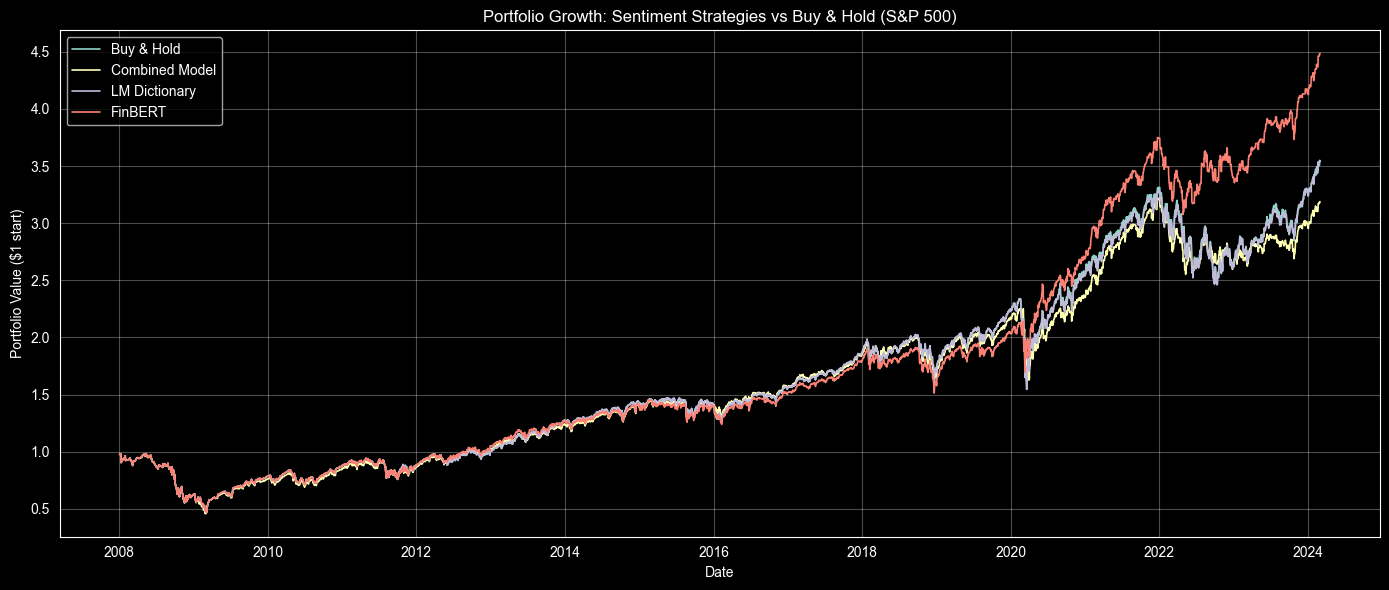

               Strategy Total Return Ann. Return
             Buy & Hold      254.55%       9.53%
Combined (LM + FinBERT)      218.82%       8.69%
     LM Dictionary Only      254.37%       9.52%
           FinBERT Only      348.62%      11.40%


In [ ]:
df_final["pred_combined"] = clf.predict(df_final[features])
df_final["pred_lm"]       = clf_lm.predict(df_final[lm_features])
df_final["pred_fin"]      = clf_fin.predict(df_final[fin_features])

df_port = pd.merge(
    df_final[["date", "pred_combined", "pred_lm", "pred_fin", "label"]],
    daily_close[["date", "return"]],
    on="date"
)

df_port["ret_combined"] = df_port["pred_combined"] * df_port["return"]
df_port["ret_lm"]       = df_port["pred_lm"] * df_port["return"]
df_port["ret_fin"]      = df_port["pred_fin"] * df_port["return"]
df_port["ret_buyhold"]  = df_port["return"]

df_port["wealth_combined"] = (1 + df_port["ret_combined"]).cumprod()
df_port["wealth_lm"]       = (1 + df_port["ret_lm"]).cumprod()
df_port["wealth_fin"]      = (1 + df_port["ret_fin"]).cumprod()
df_port["wealth_buyhold"]  = (1 + df_port["ret_buyhold"]).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(df_port["date"], df_port["wealth_buyhold"], label="Buy & Hold", linewidth=1.2)
plt.plot(df_port["date"], df_port["wealth_combined"], label="Combined Model", linewidth=1.2)
plt.plot(df_port["date"], df_port["wealth_lm"], label="LM Dictionary", linewidth=1.2)
plt.plot(df_port["date"], df_port["wealth_fin"], label="FinBERT", linewidth=1.2)

plt.title("Portfolio Growth: Sentiment Strategies vs Buy & Hold (S&P 500)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($1 start)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

def portfolio_stats(returns, name):
    total_return = (1 + returns).prod() - 1
    ann_return   = (1 + total_return) ** (252 / len(returns)) - 1
    return {
        "Strategy": name,
        "Total Return": f"{total_return:.2%}",
        "Ann. Return": f"{ann_return:.2%}"
    }

stats = pd.DataFrame([
    portfolio_stats(df_port["ret_buyhold"], "Buy & Hold"),
    portfolio_stats(df_port["ret_combined"], "Combined (LM + FinBERT)"),
    portfolio_stats(df_port["ret_lm"], "LM Dictionary Only"),
    portfolio_stats(df_port["ret_fin"], "FinBERT Only"),
])

print(stats.to_string(index=False))

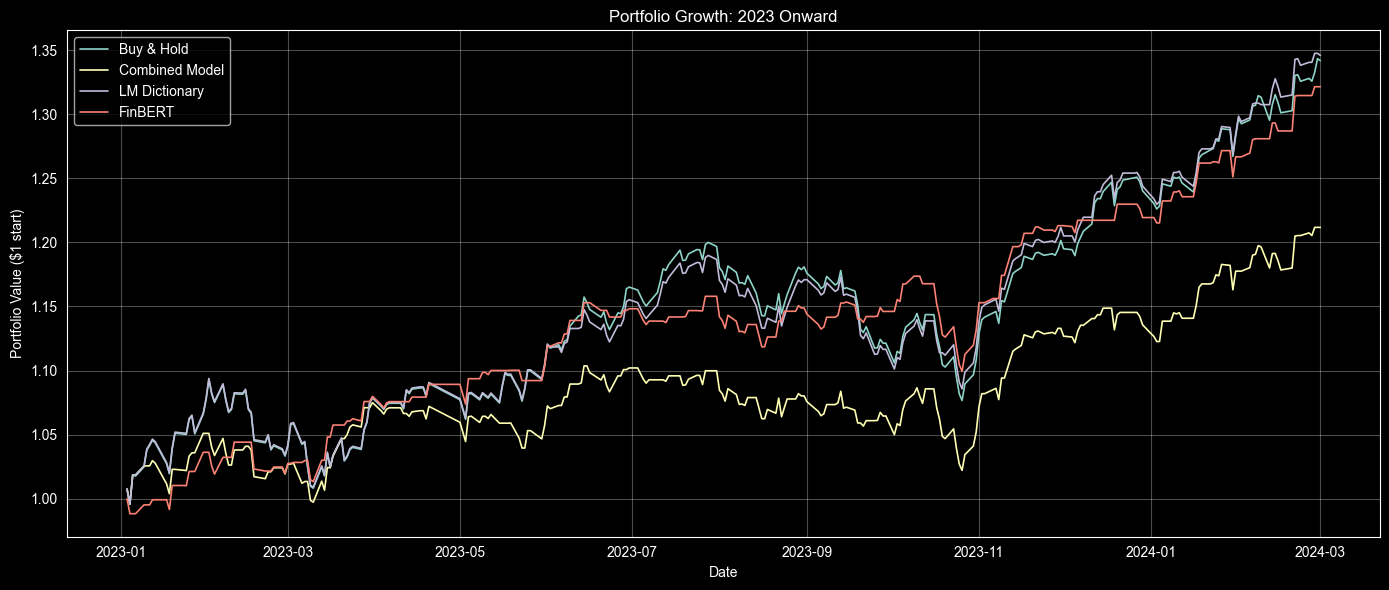

               Strategy Total Return Ann. Return
             Buy & Hold       34.17%      29.56%
Combined (LM + FinBERT)       21.17%      18.43%
     LM Dictionary Only       34.58%      29.91%
           FinBERT Only       32.14%      27.84%


In [ ]:
df_final_2023 = df_final[df_final["date"] >= "2023-01-01"].copy()
daily_close_2023 = daily_close[daily_close["date"] >= "2023-01-01"].copy()

df_final_2023["pred_combined"] = clf.predict(df_final_2023[features])
df_final_2023["pred_lm"] = clf_lm.predict(df_final_2023[lm_features])
df_final_2023["pred_fin"] = clf_fin.predict(df_final_2023[fin_features])

df_port_2023 = pd.merge(
    df_final_2023[["date", "pred_combined", "pred_lm", "pred_fin", "label"]],
    daily_close_2023[["date", "return"]],
    on="date"
)

df_port_2023["ret_combined"] = df_port_2023["pred_combined"] * df_port_2023["return"]
df_port_2023["ret_lm"] = df_port_2023["pred_lm"] * df_port_2023["return"]
df_port_2023["ret_fin"] = df_port_2023["pred_fin"] * df_port_2023["return"]
df_port_2023["ret_buyhold"] = df_port_2023["return"]

df_port_2023["wealth_combined"] = (1 + df_port_2023["ret_combined"]).cumprod()
df_port_2023["wealth_lm"] = (1 + df_port_2023["ret_lm"]).cumprod()
df_port_2023["wealth_fin"] = (1 + df_port_2023["ret_fin"]).cumprod()
df_port_2023["wealth_buyhold"] = (1 + df_port_2023["ret_buyhold"]).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(df_port_2023["date"], df_port_2023["wealth_buyhold"], label="Buy & Hold", linewidth=1.2)
plt.plot(df_port_2023["date"], df_port_2023["wealth_combined"], label="Combined Model", linewidth=1.2)
plt.plot(df_port_2023["date"], df_port_2023["wealth_lm"], label="LM Dictionary", linewidth=1.2)
plt.plot(df_port_2023["date"], df_port_2023["wealth_fin"], label="FinBERT", linewidth=1.2)
plt.title("Portfolio Growth: 2023 Onward")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($1 start)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

stats_2023 = pd.DataFrame([
    portfolio_stats(df_port_2023["ret_buyhold"], "Buy & Hold"),
    portfolio_stats(df_port_2023["ret_combined"], "Combined (LM + FinBERT)"),
    portfolio_stats(df_port_2023["ret_lm"], "LM Dictionary Only"),
    portfolio_stats(df_port_2023["ret_fin"], "FinBERT Only"),
])

print(stats_2023.to_string(index=False))